# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [1]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

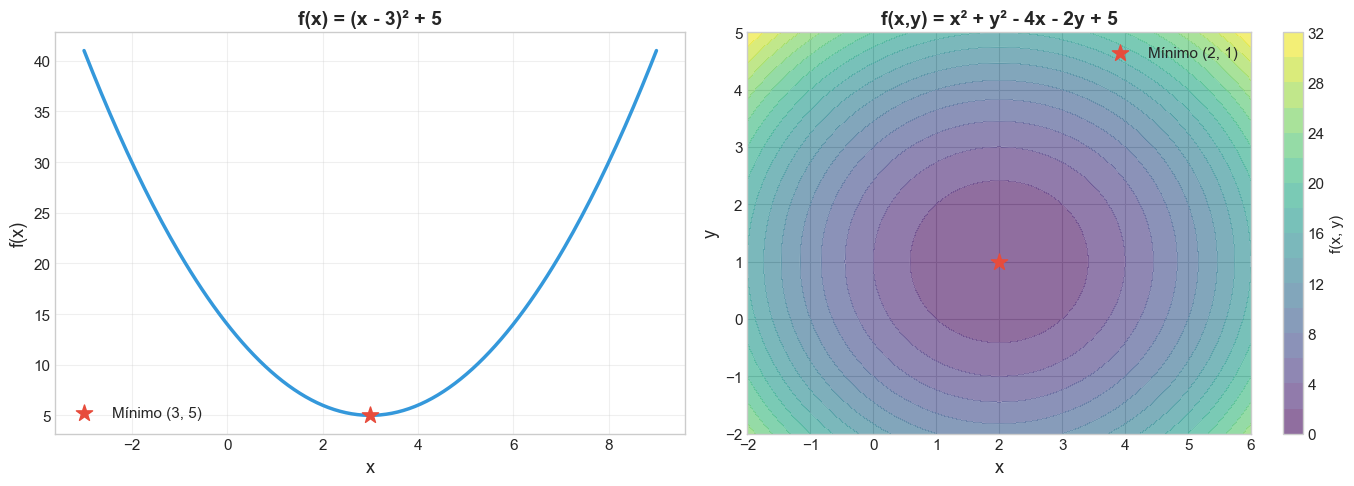

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [2]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [3]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    
    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """
    
    # 1. Inicializar variables
    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False
    iteracion = 0
    
    # 2. Loop principal
    for i in range(max_iter):
        iteracion += 1
        
        # a. Calcular el gradiente
        g = df_1d(x_actual)
        
        # b. Actualizar posicion
        x_nuevo = x_actual - learning_rate * g
        
        # c. Guardar en historial
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))
        
        # d. Verificar convergencia
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            break
        
        # e. Actualizar x_actual
        x_actual = x_nuevo
    
    # 3. Retornar resultados
    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': iteracion,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }


### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [4]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


El algoritmo funcionó perfecto, arrancando desde x = -2 con learning rate de 0.1 llegó casi exactamente al mínimo esperado (x = 3, f = 5) en 63 iteraciones, con un error tan pequeño que prácticamente es cero.

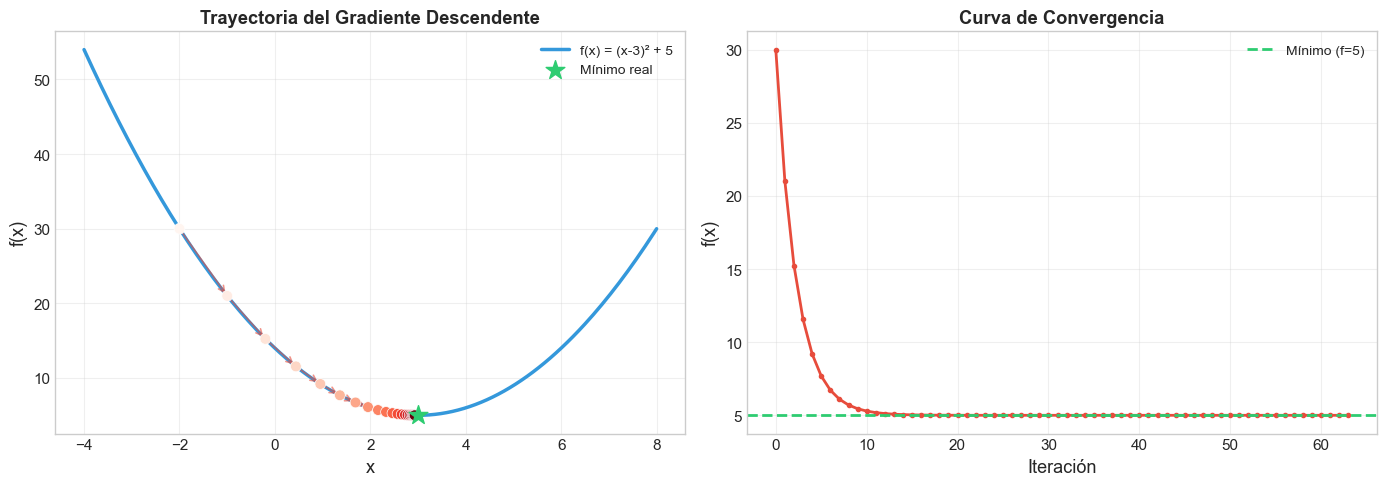

In [5]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

Se ve claramente cómo los puntos van bajando por la curva de izquierda a derecha hasta pegarse justo en la estrella verde del mínimo, y la curva de convergencia muestra que los primeros 10 pasos son donde más baja el valor, después ya solo afina los últimos decimales.

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [6]:
# ============================================================
# Ejecutar experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

# Ejecutar gradiente descendente para cada learning rate
for lr in learning_rates_prueba:
    res = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba,
        learning_rate=lr,
        max_iter=max_iter_prueba
    )
    resultados_lr.append(res)

# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergió':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")


EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


Aquí se nota bien el efecto del learning rate: 0.5 fue el más eficiente llegando al mínimo en solo 2 pasos, 0.1 tardó 63 pero llegó bien, los pequeños (0.001 y 0.01) se quedaron cortos porque 200 iteraciones no les alcanzaron, lr=1.0 se quedó paralizado rebotando en el punto de inicio, y lr=1.5 explotó completamente generando un número tan ridículamente grande que ni cabe en la pantalla.

### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

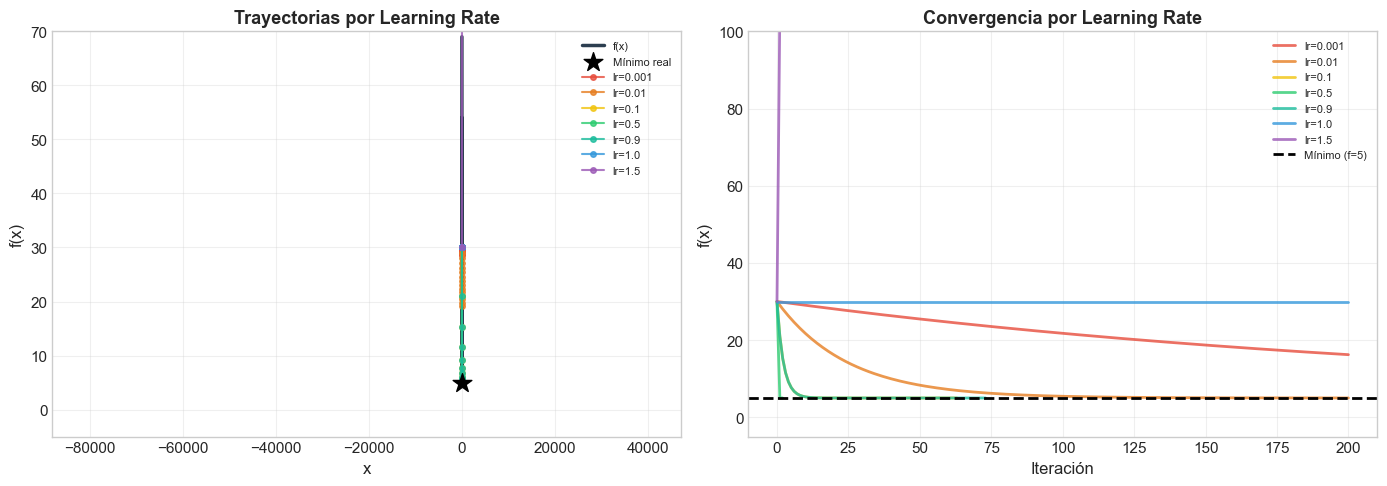

Gráfica guardada como 'comparacion_learning_rates.png'


In [7]:
# ============================================================
# Grafica comparativa de learning rates
# ============================================================

import matplotlib.cm as cm

colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#1abc9c', '#3498db', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre f(x) para cada LR ---
x_range = np.linspace(-5, 10, 300)
axes[0].plot(x_range, f_1d(x_range), color='#2c3e50', linewidth=2.5, label='f(x)', zorder=1)
axes[0].scatter([3], [5], color='black', s=200, marker='*', zorder=6, label='Mínimo real')

for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    hx = res['historial_x']
    hf = res['historial_f']
    n = min(15, len(hx))
    axes[0].plot(hx[:n], hf[:n], 'o-', color=color, markersize=4,
                 linewidth=1.5, alpha=0.8, label=f'lr={lr}')

axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('f(x)', fontsize=12)
axes[0].set_title('Trayectorias por Learning Rate', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-5, 70)

# --- Grafica 2: Curva de convergencia f(x) vs iteracion ---
for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    hf = res['historial_f']
    # Solo mostrar si los valores son razonables
    hf_clipped = [min(v, 200) for v in hf]
    axes[1].plot(range(len(hf_clipped)), hf_clipped, '-', color=color,
                 linewidth=2, alpha=0.8, label=f'lr={lr}')

axes[1].axhline(y=5, color='black', linestyle='--', linewidth=2, label='Mínimo (f=5)')
axes[1].set_xlabel('Iteración', fontsize=12)
axes[1].set_ylabel('f(x)', fontsize=12)
axes[1].set_title('Convergencia por Learning Rate', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-5, 100)

plt.tight_layout()
plt.savefig('comparacion_learning_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'comparacion_learning_rates.png'")


La gráfica de trayectorias está completamente destrozada por lr=1.5, que jala el eje x a escala de 80,000 haciendo que todo lo demás se vea aplastado en una línea vertical. En la curva de convergencia se ve más claro: lr=1.0 se queda plano sin bajar nunca, lr=0.001 y 0.01 bajan pero lento y no llegan al mínimo punteado, mientras que lr=0.5 y 0.9 son los únicos que llegan abajo rápido.

**Responde estas preguntas basandote en tus experimentos:**

1. **\u00bfQu\u00e9 pasa con un learning rate muy peque\u00f1o (0.001)?**
   - *Tu respuesta: El algoritmo avanza pero a pasitos tan chiquitos que en 200 iteraciones ni siquiera llega al mínimo, se queda a mitad del camino. Técnicamente va en la dirección correcta, solo que necesitaría miles de pasos para llegar.*

2. **\u00bfCu\u00e1l consideras el mejor learning rate y por qu\u00e9?**
   - *Tu respuesta: El 0.5, porque llegó al mínimo exacto en solo 2 iteraciones sin ningún problema. Es el punto donde el paso es lo suficientemente grande para avanzar rápido pero sin pasarse y perder el control.*

3. **\u00bfQu\u00e9 pasa con learning rates >= 1.0?**
   - *Tu respuesta: Se rompe todo. Con 1.0 el algoritmo se queda atascado rebotando sin moverse del punto inicial, y con 1.5 los valores explotan a números absurdamente grandes porque cada paso en lugar de acercarte al mínimo te lanza más lejos en dirección contraria.*

4. **\u00bfPor qu\u00e9 un learning rate de exactamente 1.0 tiene un comportamiento especial para esta funci\u00f3n?**
   - *Tu respuesta: Porque la derivada de esta función es 2(x-3), entonces al actualizar haces x = x - 1.0 * 2(x-3), que simplifica a x = -x + 6. Si arrancas en x = -2, el siguiente paso te da x = 8, luego vuelve a -2, luego a 8... rebota infinitamente entre los mismos dos puntos sin converger nunca. Es un caso exacto donde el paso cancela y revierte el movimiento en lugar de reducirlo.*

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [8]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    
    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """
    
    # 1. Inicializar variables
    x_actual = x_inicial
    y_actual = y_inicial
    historial_x = [x_inicial]
    historial_y = [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False
    iteracion = 0
    
    # 2. Loop principal
    for i in range(max_iter):
        iteracion += 1
        
        # a. Calcular gradiente: [df/dx, df/dy]
        g = grad_2d(x_actual, y_actual)
        
        # b. Actualizar ambos parámetros simultáneamente
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]
        
        # c. Guardar en historiales
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))
        
        # d. Verificar convergencia usando la norma del gradiente
        if np.linalg.norm(g) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            y_actual = y_nuevo
            break
        
        # e. Actualizar x_actual, y_actual
        x_actual = x_nuevo
        y_actual = y_nuevo
    
    # 3. Retornar resultados
    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': iteracion,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }


### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [9]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)



En 2D también funcionó perfecto, partiendo de (-1, 4) llegó exactamente a (2, 1) con f = 0 en 73 iteraciones, apenas 10 pasos más que el caso 1D, lo cual tiene sentido porque ahora tiene que mover dos coordenadas al mismo tiempo.

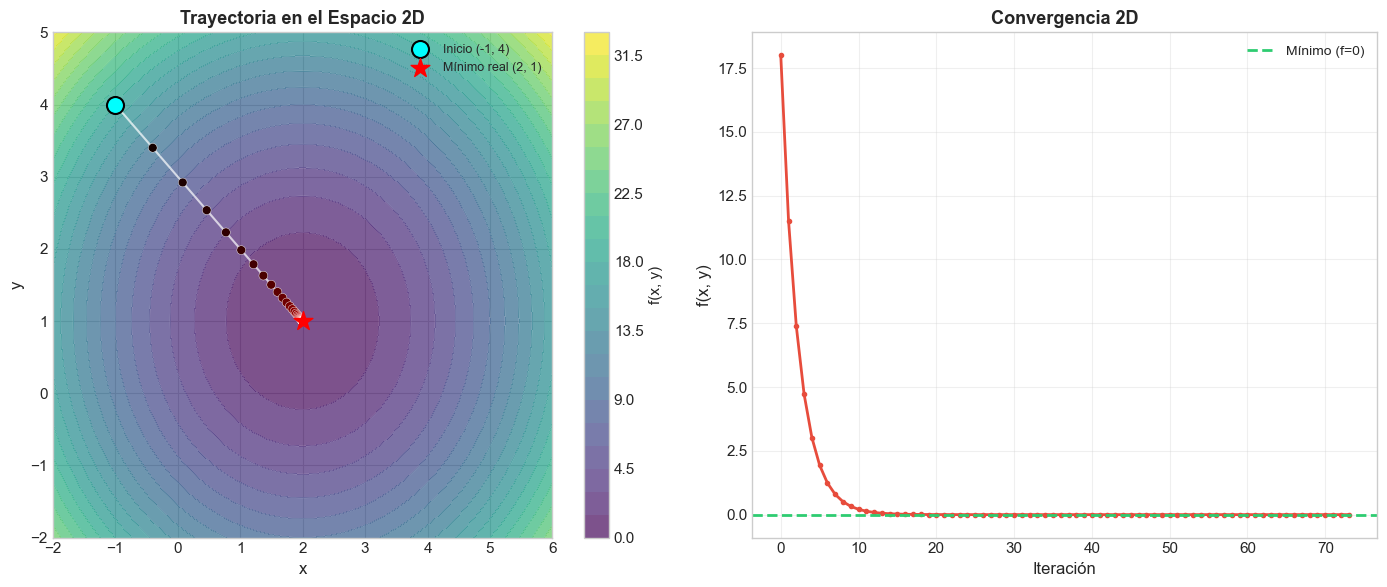

Gráfica guardada como 'gd_2d_trayectoria.png'


In [10]:
# ============================================================
# Visualizacion del gradiente descendente 2D
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Crear mapa de contornos ---
x_range = np.linspace(-2, 6, 200)
y_range = np.linspace(-2, 5, 200)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_grid = f_2d(X_grid, Y_grid)

# --- Grafica 1: Mapa de contornos con trayectoria ---
contourf = axes[0].contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.7)
axes[0].contour(X_grid, Y_grid, Z_grid, levels=25, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contourf, ax=axes[0], label='f(x, y)')

# Trayectoria
hx2d = resultado_2d['historial_x']
hy2d = resultado_2d['historial_y']
n_pasos = len(hx2d)
scatter = axes[0].scatter(hx2d, hy2d, c=range(n_pasos), cmap='hot',
                           s=40, zorder=5, edgecolors='white', linewidth=0.3)
axes[0].plot(hx2d, hy2d, '-', color='white', linewidth=1.5, alpha=0.7)

# Punto inicial y mínimo
axes[0].scatter([hx2d[0]], [hy2d[0]], color='cyan', s=150, marker='o',
                zorder=6, edgecolors='black', linewidth=1.5, label='Inicio (-1, 4)')
axes[0].scatter([2], [1], color='red', s=200, marker='*',
                zorder=6, label='Mínimo real (2, 1)')

axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Trayectoria en el Espacio 2D', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=9)

# --- Grafica 2: Convergencia ---
hf2d = resultado_2d['historial_f']
axes[1].plot(range(len(hf2d)), hf2d, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=0, color='#2ecc71', linestyle='--', linewidth=2, label='Mínimo (f=0)')
axes[1].set_xlabel('Iteración', fontsize=12)
axes[1].set_ylabel('f(x, y)', fontsize=12)
axes[1].set_title('Convergencia 2D', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_2d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'gd_2d_trayectoria.png'")


La trayectoria en el mapa de contornos va en línea casi recta desde el círculo azul hasta la estrella roja atravesando los anillos de color como quien baja directo al centro. La curva de convergencia tiene la misma forma que en 1D: caída brusca en los primeros 10 pasos y luego se aplana pegándose al cero.

COMPARACIÓN DE PUNTOS INICIALES EN 2D
         Inicio          (x,y) final    f final    Iters
------------------------------------------------------------
( -1.0,   4.0)  (  2.0000,   1.0000)    0.000000        73
(  5.0,  -1.0)  (  2.0000,   1.0000)    0.000000        72
(  0.0,   0.0)  (  2.0000,   1.0000)    0.000000        70


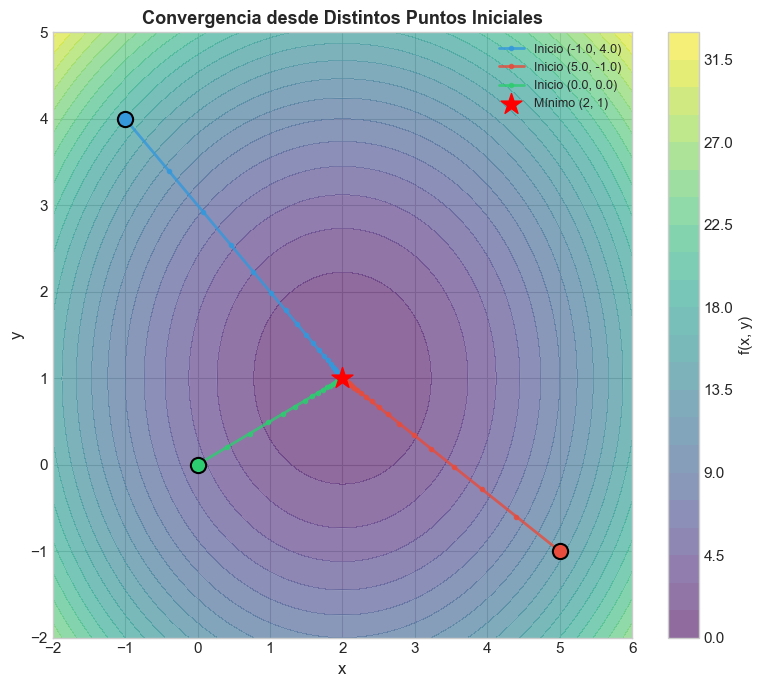


Gráfica guardada como 'gd_2d_multiples_puntos.png'


In [11]:
# ============================================================
# Prueba con diferentes puntos iniciales en 2D
# ============================================================

puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

colores_2d = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Mapa de contornos
contourf = ax.contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.6)
ax.contour(X_grid, Y_grid, Z_grid, levels=25, colors='white', alpha=0.2, linewidths=0.5)
plt.colorbar(contourf, ax=ax, label='f(x, y)')

print("COMPARACIÓN DE PUNTOS INICIALES EN 2D")
print("=" * 60)
print(f"{'Inicio':>15} {'(x,y) final':>20} {'f final':>10} {'Iters':>8}")
print("-" * 60)

for (xi, yi), color in zip(puntos_iniciales, colores_2d):
    res = gradiente_descendente_2d(
        x_inicial=xi, y_inicial=yi,
        learning_rate=0.1, max_iter=200
    )
    hx = res['historial_x']
    hy = res['historial_y']
    
    # Graficar trayectoria
    ax.plot(hx, hy, 'o-', color=color, markersize=3, linewidth=2, alpha=0.8,
            label=f'Inicio ({xi}, {yi})')
    ax.scatter([xi], [yi], color=color, s=120, marker='o', zorder=5,
               edgecolors='black', linewidth=1.5)
    
    print(f"({xi:>5.1f}, {yi:>5.1f})  "
          f"({res['x_final']:>8.4f}, {res['y_final']:>8.4f})  "
          f"{res['f_final']:>10.6f}  {res['iteraciones']:>8}")

# Mínimo real
ax.scatter([2], [1], color='red', s=250, marker='*', zorder=6, label='Mínimo (2, 1)')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Convergencia desde Distintos Puntos Iniciales', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('gd_2d_multiples_puntos.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfica guardada como 'gd_2d_multiples_puntos.png'")


Lo más interesante aquí es que los tres puntos iniciales, sin importar desde dónde empiecen, todos llegan exactamente al mismo mínimo (2, 1) con f = 0, y además en tiempos muy similares: 73, 72 y 70 iteraciones. Eso confirma que para esta función no importa de dónde partas, el gradiente siempre te guía al mismo lugar, y la gráfica lo muestra perfecto con las tres líneas convergiendo a la misma estrella roja desde distintas esquinas.

---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [12]:
# ============================================================
# Genera el DataFrame con todos los experimentos
# ============================================================

import numpy as np

filas = []

# --- Experimentos 1D ---
lr_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
for lr in lr_1d:
    res = gradiente_descendente_1d(x_inicial=-2.0, learning_rate=lr, max_iter=200)
    filas.append({
        'learning_rate': lr,
        'dimension': '1D',
        'x_inicial': -2.0,
        'y_inicial': np.nan,
        'x_final': res['x_final'],
        'y_final': np.nan,
        'valor_minimo': res['f_final'],
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido']
    })

# --- Experimentos 2D ---
lr_2d = [0.001, 0.01, 0.1, 0.5]
puntos_2d = [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]

for xi, yi in puntos_2d:
    for lr in lr_2d:
        res = gradiente_descendente_2d(
            x_inicial=xi, y_inicial=yi,
            learning_rate=lr, max_iter=500
        )
        filas.append({
            'learning_rate': lr,
            'dimension': '2D',
            'x_inicial': xi,
            'y_inicial': yi,
            'x_final': res['x_final'],
            'y_final': res['y_final'],
            'valor_minimo': res['f_final'],
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido']
        })

# Crear DataFrame
df_experimentos = pd.DataFrame(filas)

# Guardar CSV
df_experimentos.to_csv('experimentos_gd.csv', index=False)

print("CSV generado exitosamente: 'experimentos_gd.csv'")
print(f"Total de experimentos: {len(df_experimentos)}")
print("\nPreview del DataFrame:")
print(df_experimentos.to_string(index=False))


CSV generado exitosamente: 'experimentos_gd.csv'
Total de experimentos: 19

Preview del DataFrame:
 learning_rate dimension  x_inicial  y_inicial       x_final  y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01      NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00      NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999996e+00      NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00      NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  3.000000e+00      NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00      NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60      NaN 6.455625e+121          200       False
         0.001        2D     

In [13]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_reload = pd.read_csv('experimentos_gd.csv')
print(df_reload.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_reload)}")


CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final  y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01      NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00      NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999996e+00      NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00      NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  3.000000e+00      NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00      NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60      NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0  8.974662e-01 2.102534  2.431161e+00          5

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **\u00bfCu\u00e1l es el rango de learning rates que funciona bien para estas funciones?**
   - *Tu respuesta: Entre 0.1 y 0.9 funciona bien. Con 0.5 fue el punto dulce porque llegó en solo 2 pasos, y cualquier cosa por debajo de 0.1 avanza demasiado lento, mientras que desde 1.0 hacia arriba ya se rompe*

2. **\u00bfEl punto inicial afecta si el algoritmo converge? \u00bfAfecta cu\u00e1ntas iteraciones necesita?**
   - *Tu respuesta: Para estas funciones el punto inicial no afecta si converge o no, siempre llega al mismo mínimo. Sí afecta un poco cuántas iteraciones necesita, pero apenas: los tres puntos que probamos tardaron 70, 72 y 73 pasos, diferencias casi despreciables.*

3. **\u00bfQu\u00e9 pasar\u00eda si la funci\u00f3n tuviera m\u00faltiples m\u00ednimos locales? (piensa en una funci\u00f3n como `sin(x) + x\u00b2/10`)**
   - *Tu respuesta: Ahí sí el punto inicial importaría muchísimo, porque el gradiente solo ve la pendiente local y te arrastra al mínimo más cercano, no necesariamente al mejor. Si arrancas cerca de un hoyo chico caes ahí y el algoritmo cree que terminó, aunque exista un hoyo más profundo lejos.*

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la funci\u00f3n de costo es como `f(x,y)`. \u00bfPor qu\u00e9 es importante elegir bien el learning rate al entrenar?**
   - *Tu respuesta: Porque si es muy pequeño el entrenamiento tarda una eternidad y puede que nunca llegue a un buen resultado en tiempo razonable, y si es muy grande los pesos del modelo se disparan y el entrenamiento explota. El learning rate bien elegido es la diferencia entre un modelo que aprende bien y uno que nunca converge.*

5. **\u00bfQu\u00e9 ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - *Tu respuesta: El gradiente te dice exactamente hacia dónde bajar, es como tener un mapa de la pendiente bajo tus pies en cada paso. Probar al azar sería como caminar con los ojos cerrados esperando encontrar el valle por suerte, lo cual en problemas con miles de parámetros como una red neuronal sería completamente inviable.*

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_